In [1]:
library(Seurat)
library(symphony)
library(qs)
library(ggplot2)
library(glue)
library(scico)
library(RColorBrewer)
library(patchwork)
library(stringr)
library(Polychrome)
library(ggsci)
library(readxl)
library(SingleCellExperiment)
library(scCustomize)
library(ggbeeswarm)
library(miloR)
library(ggtree)
library(dplyr)
library(tidyr)

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.4.2”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘qs’ was built under R version 4.4.3”
qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘patchwork’ was built under R version 4.4.3”
Warning message:
“package ‘readxl’ was built under R version 4.4.3”
Warning message:
“package ‘SingleCellExperiment’ was built under R version 4.4.2”
Loading required package: SummarizedExperiment

Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.4.2”
Loading required package: MatrixGenerics

Warning message:
“pac

In [2]:
all_fibroblast_subset_query_obj <- list.files("/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/fibroblast_seurat", full.names=TRUE)
all_fibroblast_subset_query_obj <- lapply(all_fibroblast_subset_query_obj, function(file){
    qread(file) -> obj.tmp
    DefaultAssay(obj.tmp) <- "RNA"
    obj.tmp[["SCT"]] <- NULL
    obj.tmp
})

In [3]:
merged_fibroblast_query <- merge(all_fibroblast_subset_query_obj[[1]],
                                 all_fibroblast_subset_query_obj[-1])
merged_fibroblast_query <- JoinLayers(merged_fibroblast_query)
merged_fibroblast_query <- NormalizeData(merged_fibroblast_query, normalization.method="LogNormalize", scale.factor=10000)

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Normalizing layer: counts



# Get query data for reference mapping

In [6]:
query_expression <- GetAssayData(merged_fibroblast_query, layer="data", assay="RNA")
query_metadata <- merged_fibroblast_query@meta.data

# Get reference data for reference mapping

In [4]:
reference_data <- readRDS("/data1/deyk/harry/RA_Xenium/data/Zhang_Nat_2023_AMP/fibroblast_reference.rds")
reference_data$save_uwot_path <- "/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/AMP_fibroblast_umap_model/fibroblast_uwot_model.tgz"

# Reference mapping

In [7]:
query_result <- symphony::mapQuery(exp_query=query_expression,
                                   metadata_query=query_metadata,
                                   ref_obj=reference_data,
                                   vars="orig.ident",
                                   verbose=TRUE,
                                   do_normalize=FALSE,
                                   do_umap=TRUE)

Scaling and synchronizing query gene expression

Found 5636 out of 5811 reference variable genes in query dataset

Project query cells using reference gene loadings

Clustering query cells to reference centroids

Correcting query batch effects

UMAP

All done!



In [8]:
query_result <- symphony::knnPredict(query_obj=query_result,
                                     ref_obj=reference_data,
                                     train_labels=reference_data$meta_data$cluster_name,
                                     k=5,
                                     save_as="projected_cell_label",
                                     confidence=TRUE,
                                     seed=99)

In [9]:
qsave(query_result, "/data1/deyk/harry/RA_Xenium/results/Ian_old_scRNA/reference_mapped_AMP_fibroblast.qs")

In [10]:
query_result <- qread("/data1/deyk/harry/RA_Xenium/results/Ian_old_scRNA/reference_mapped_AMP_fibroblast.qs")

# Visualize results

In [31]:
cluster_colors <- brewer.pal(n=12, name="Paired")
cluster_colors <- c(cluster_colors[1:8], cluster_colors[12], cluster_colors[10])
lvls <- unique(reference_data$meta_data$cluster_name)
lvls <- lvls[!grepl("Mu", lvls)]
nums <- as.integer( sub("^F-(\\d+):.*$", "\\1", lvls) )
lvls_sorted <- lvls[ order(nums) ]
lvls_sorted <- c(lvls_sorted, "Mu-0: Mural")
names(cluster_colors) <- lvls_sorted

In [33]:
lining_intermediate <- c("F-0:", "F-1", "F-8")
sublining <- c("F-2:", "F-3:", "F-4:", "F-5", "F-6:", "F-7:")
mural <- ("Mu-0:")
cluster_list <- list("Lining/Intermediate"=lining_intermediate,
                     "Sublining"=sublining,
                     "Mural"=mural)
unlist(lapply(names(cluster_list), function(high_level_ct){
    pattern <- paste(cluster_list[[high_level_ct]], collapse="|")
    lvls_sorted[str_detect(lvls_sorted, regex(pattern))] -> fine_grained_ct
    mapping.tmp <- rep(high_level_ct, length(fine_grained_ct))
    names(mapping.tmp) <- fine_grained_ct
    mapping.tmp
})) -> high_level_ct_mapping

In [36]:
plot_data <- data.frame(query_result$umap)
plot_data <- cbind(plot_data, query_result$meta_data %>% select(orig.ident, projected_cell_label, projected_cell_label_prob, orig.ident))
plot_data$projected_cell_label <- factor(plot_data$projected_cell_label, levels=lvls_sorted)
plot_data$high_level_ct <- high_level_ct_mapping[as.character(plot_data$projected_cell_label)]

In [37]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 500)
ggplot(plot_data, aes(UMAP1, UMAP2, color=projected_cell_label)) +
    geom_point(size=0.5, stroke=0) +
    scale_color_manual(values=cluster_colors, guide="none") +
    theme_bw() +
    theme(legend.key.height=unit(0.4, 'cm'),
          plot.title=element_text(face="bold"),
          legend.key.width=unit(0.35, 'cm'),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7),
          panel.grid = element_blank(),
          axis.text=element_blank(),
          axis.ticks=element_blank()) +
    coord_fixed() +
    labs(color="") +
    ggtitle("Query") -> query_umap

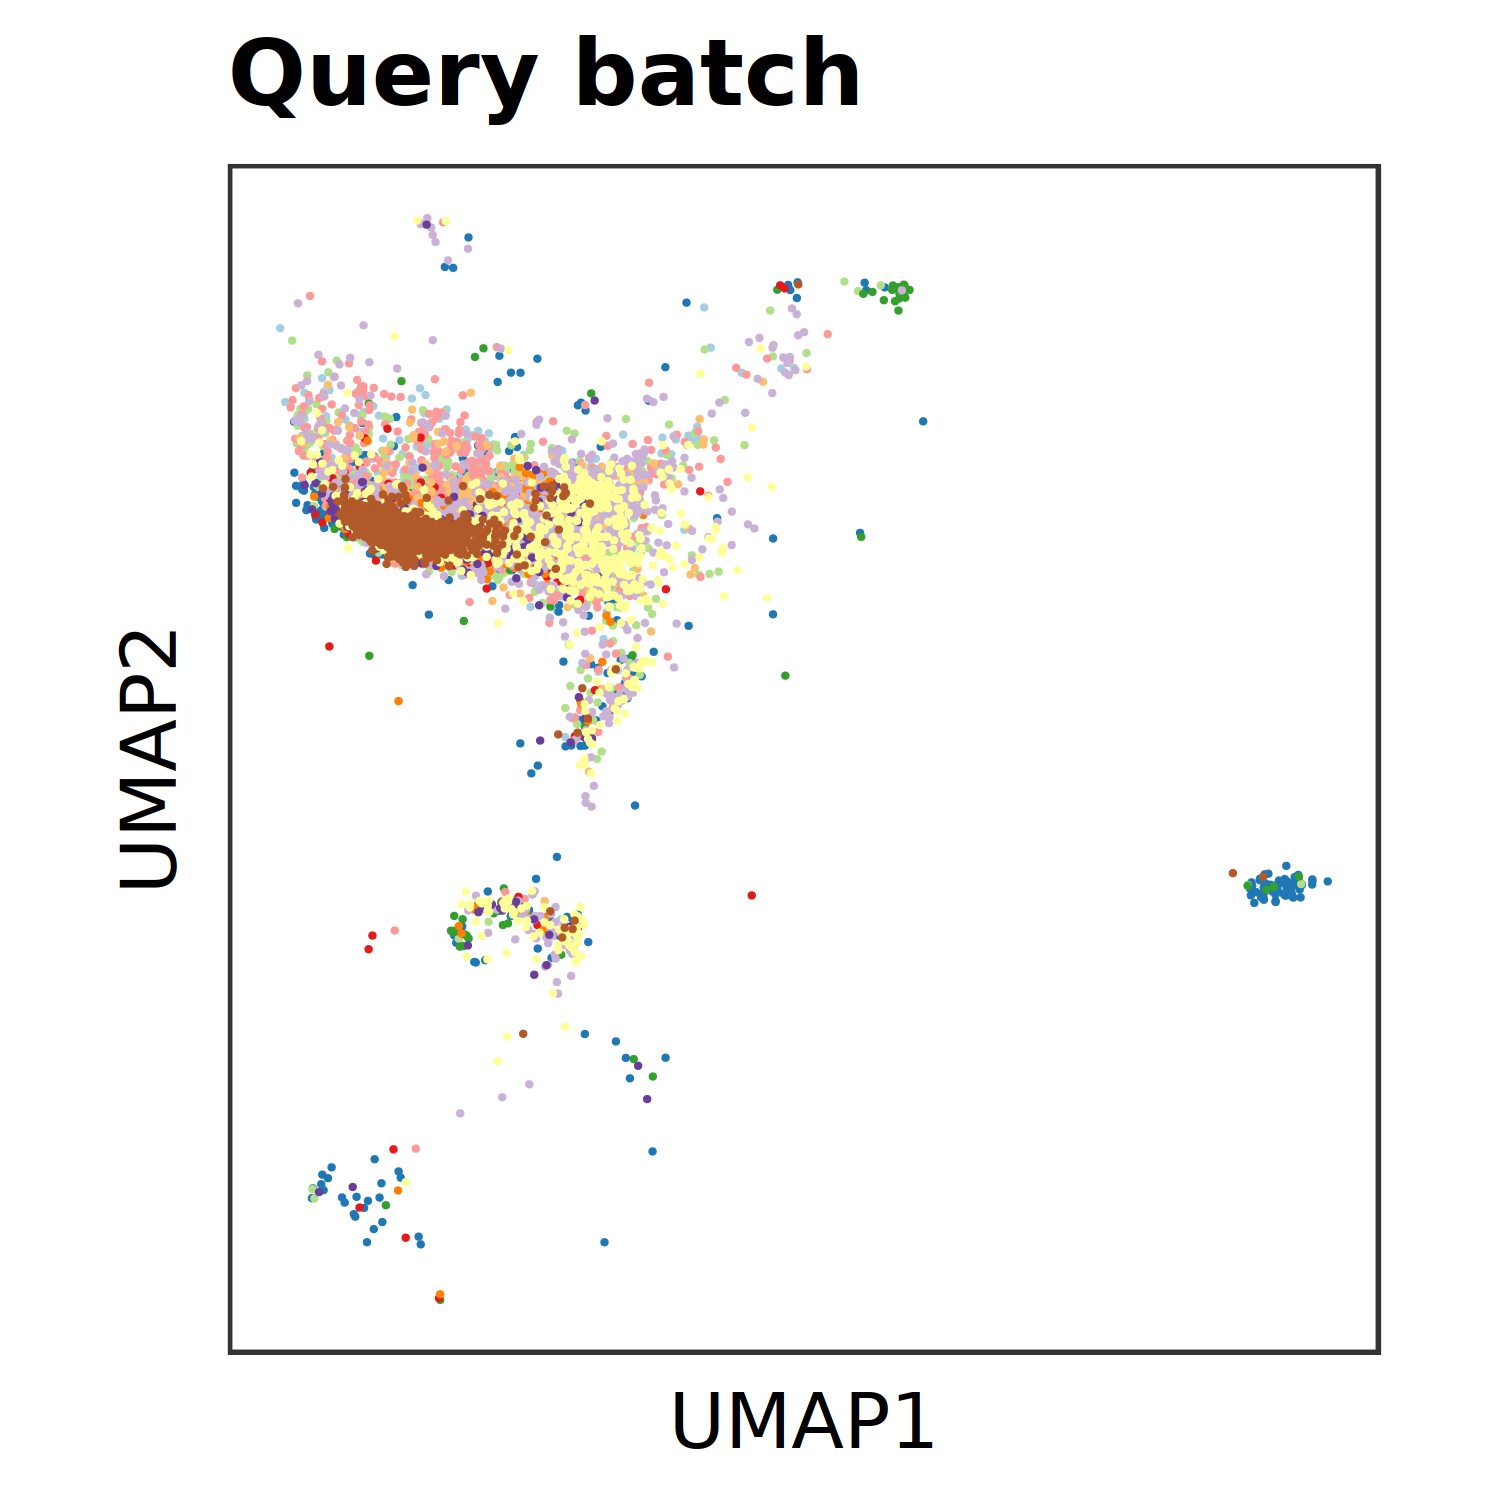

In [39]:
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 500)
ggplot(plot_data, aes(UMAP1, UMAP2, color=orig.ident)) +
    geom_point(size=0.5, stroke=0) +
    scale_color_manual(values=brewer.pal("Paired", n=12), guide="none") +
    theme_bw() +
    theme(legend.key.height=unit(0.4, 'cm'),
          plot.title=element_text(face="bold"),
          legend.key.width=unit(0.35, 'cm'),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7),
          panel.grid = element_blank(),
          axis.text=element_blank(),
          axis.ticks=element_blank()) +
    coord_fixed() +
    labs(color="") +
    ggtitle("Query batch")

In [41]:
reference_plot_data <- data.frame(reference_data$umap$embedding)
reference_plot_data <- cbind(reference_plot_data, reference_data$meta_data %>% select(cluster_name))
reference_plot_data$cluster_name <- factor(reference_plot_data$cluster_name, levels=lvls_sorted)
reference_plot_data$high_level_ct <- high_level_ct_mapping[as.character(reference_plot_data$cluster_name)]

In [42]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 500)
ggplot(reference_plot_data, aes(UMAP1, UMAP2, color=cluster_name)) +
    geom_point(size=0.5, stroke=0) +
    scale_color_manual(values=cluster_colors) +
    theme_bw() +
    theme(legend.key.height=unit(0.4, 'cm'),
          plot.title=element_text(face="bold"),
          legend.key.width=unit(0.35, 'cm'),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7),
          panel.grid = element_blank(),
          axis.text=element_blank(),
          axis.ticks=element_blank()) +
    coord_fixed() +
    labs(color="") +
    guides(colour = guide_legend(override.aes=list(size=2))) +
    ggtitle("Reference") -> reference_umap

## Fine-grained cell type level

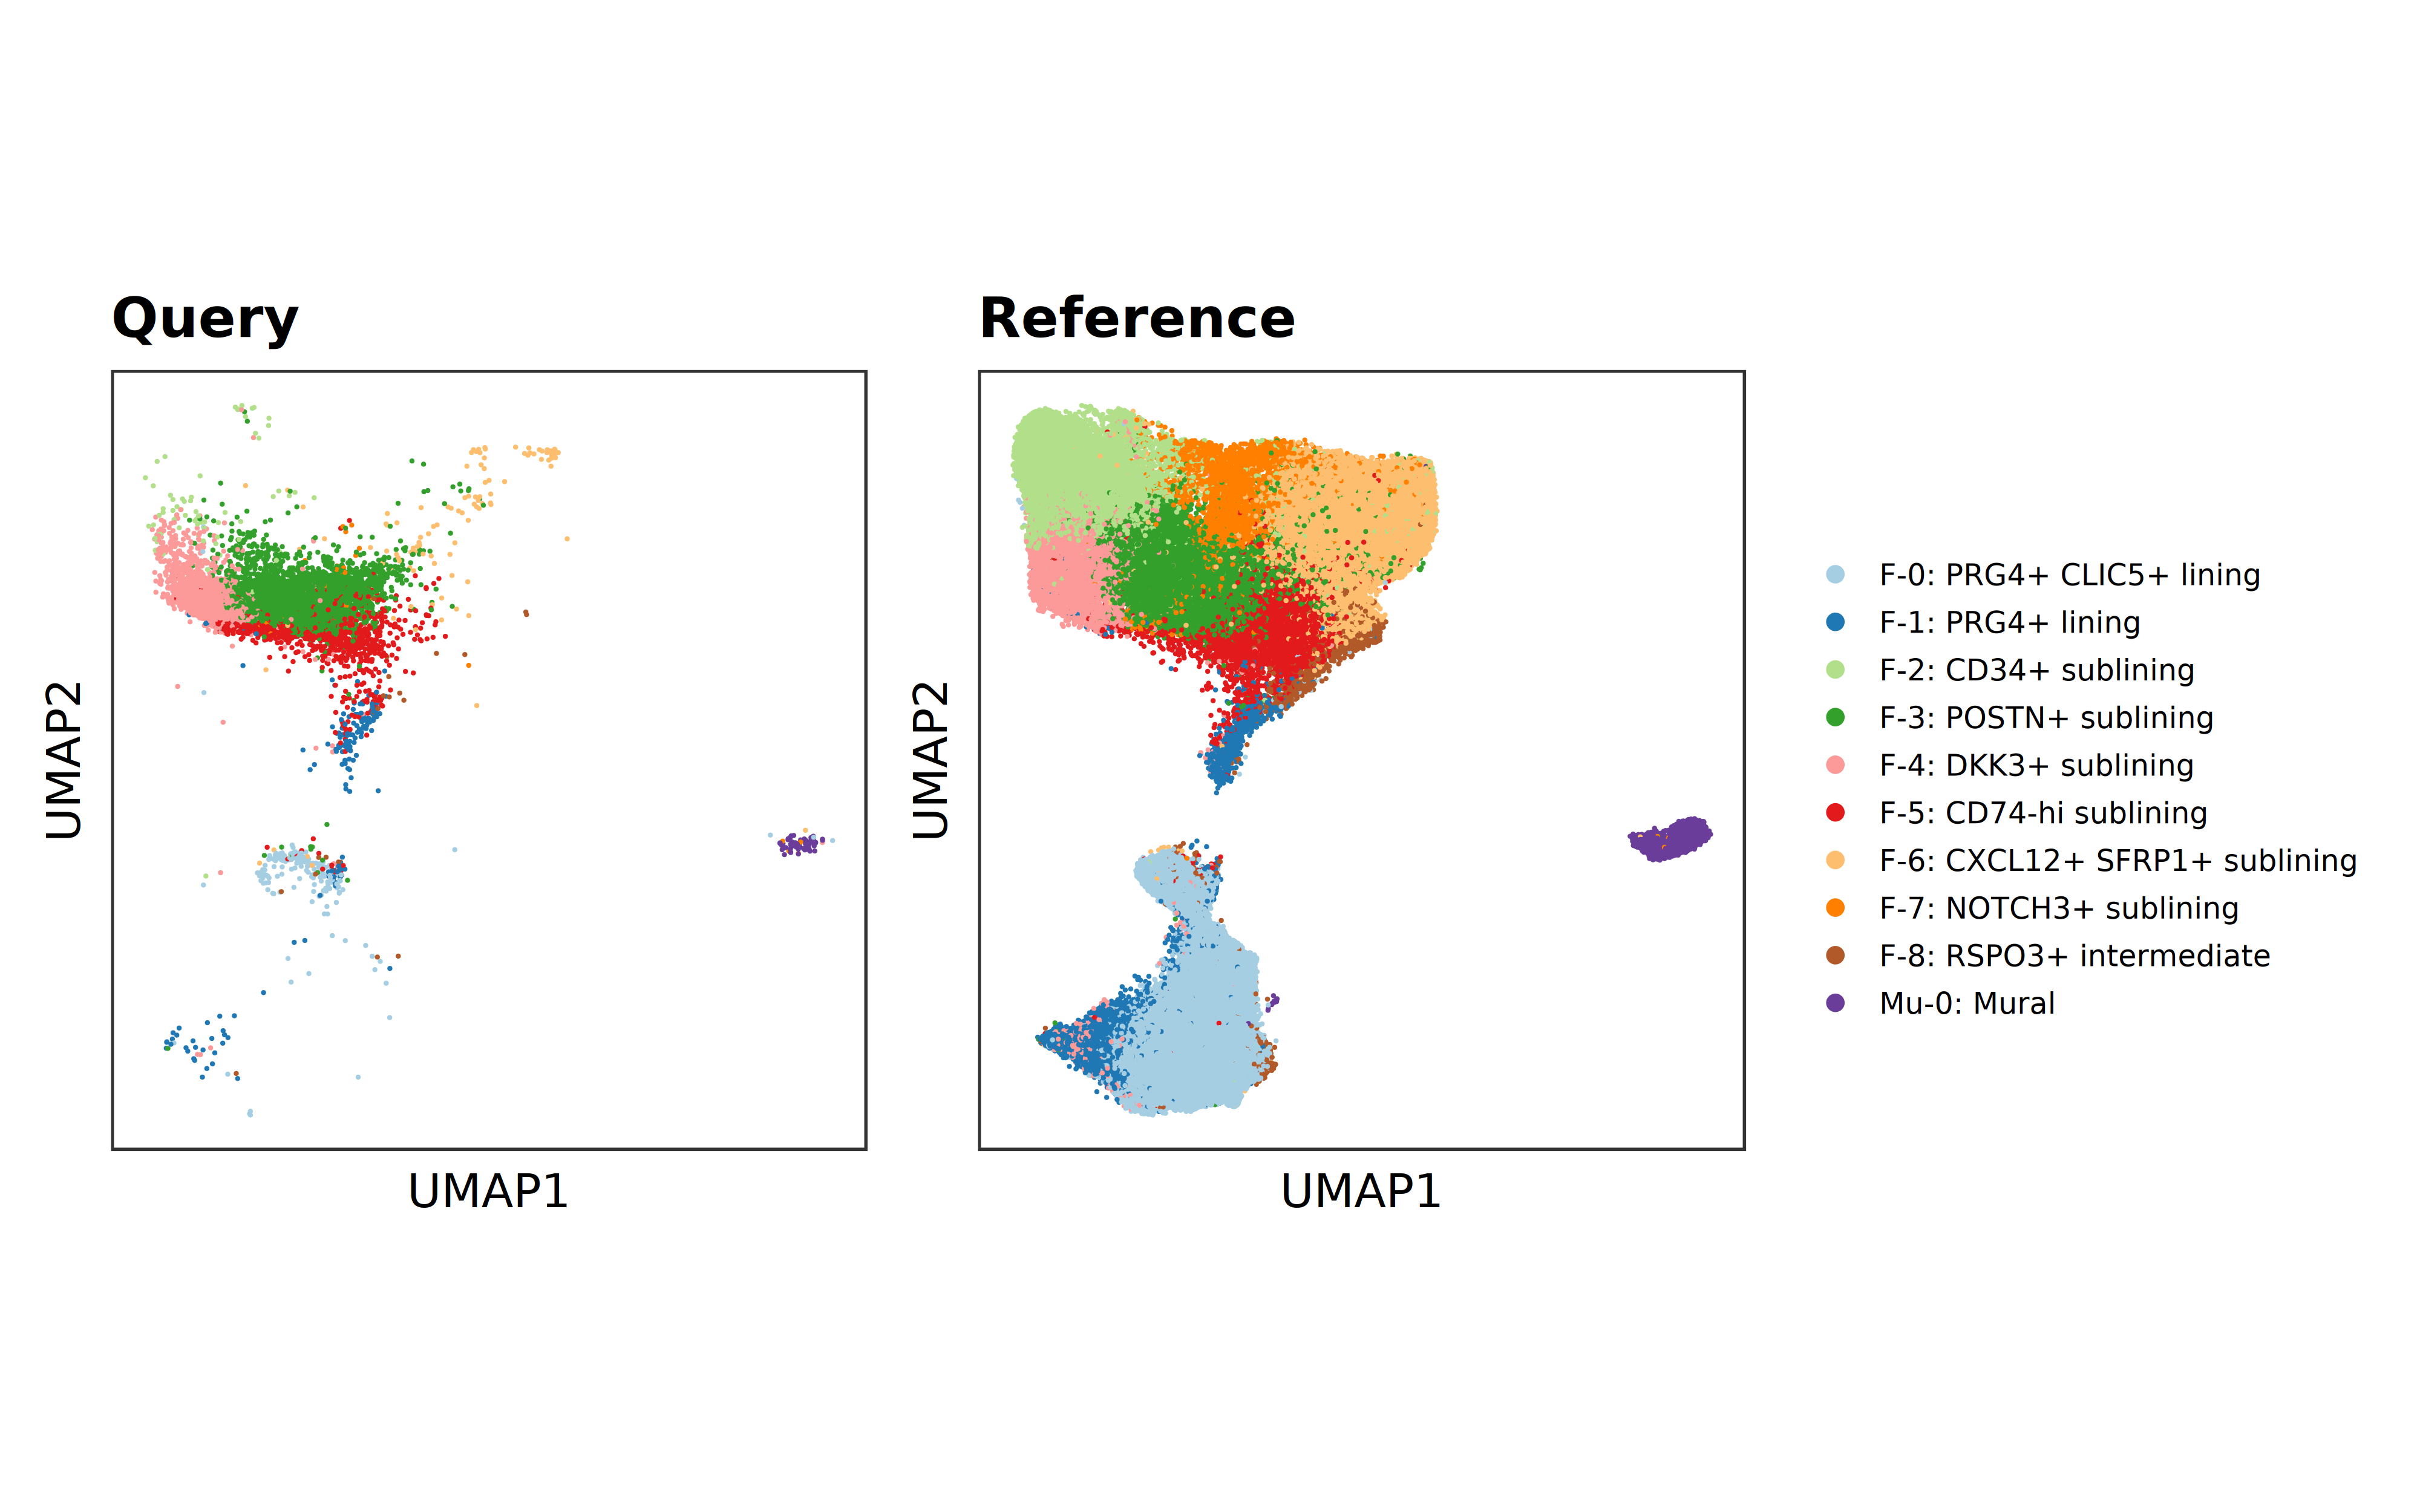

In [44]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 500)
query_umap + reference_umap
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/Ian_old_scrna_experiment/reference_mapping_umap_FB.png",
       height=5,
       width=8,
       dpi=500)

## Higher level cell type 

In [45]:
high_level_ct_pal <- brewer.pal("Dark2", n=4)
high_level_ct_pal <- high_level_ct_pal[-1]
names(high_level_ct_pal) <- unique(high_level_ct_mapping)
ggplot(plot_data, aes(UMAP1, UMAP2, color=high_level_ct)) +
    geom_point(size=0.5, stroke=0) +
    scale_color_manual(values=high_level_ct_pal, guide="none") +
    theme_bw() +
    theme(legend.key.height=unit(0.4, 'cm'),
          plot.title=element_text(face="bold"),
          legend.key.width=unit(0.35, 'cm'),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7),
          panel.grid = element_blank(),
          axis.text=element_blank(),
          axis.ticks=element_blank()) +
    coord_fixed() +
    labs(color="") +
    ggtitle("Query") -> query_umap_high_level

In [46]:
ggplot(reference_plot_data, aes(UMAP1, UMAP2, color=high_level_ct)) +
    geom_point(size=0.5, stroke=0) +
    scale_color_manual(values=high_level_ct_pal) +
    theme_bw() +
    theme(legend.key.height=unit(0.4, 'cm'),
          plot.title=element_text(face="bold"),
          legend.key.width=unit(0.35, 'cm'),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7),
          panel.grid = element_blank(),
          axis.text=element_blank(),
          axis.ticks=element_blank()) +
    coord_fixed() +
    labs(color="") +
    guides(colour = guide_legend(override.aes=list(size=2))) +
    ggtitle("Reference") -> reference_umap_high_level

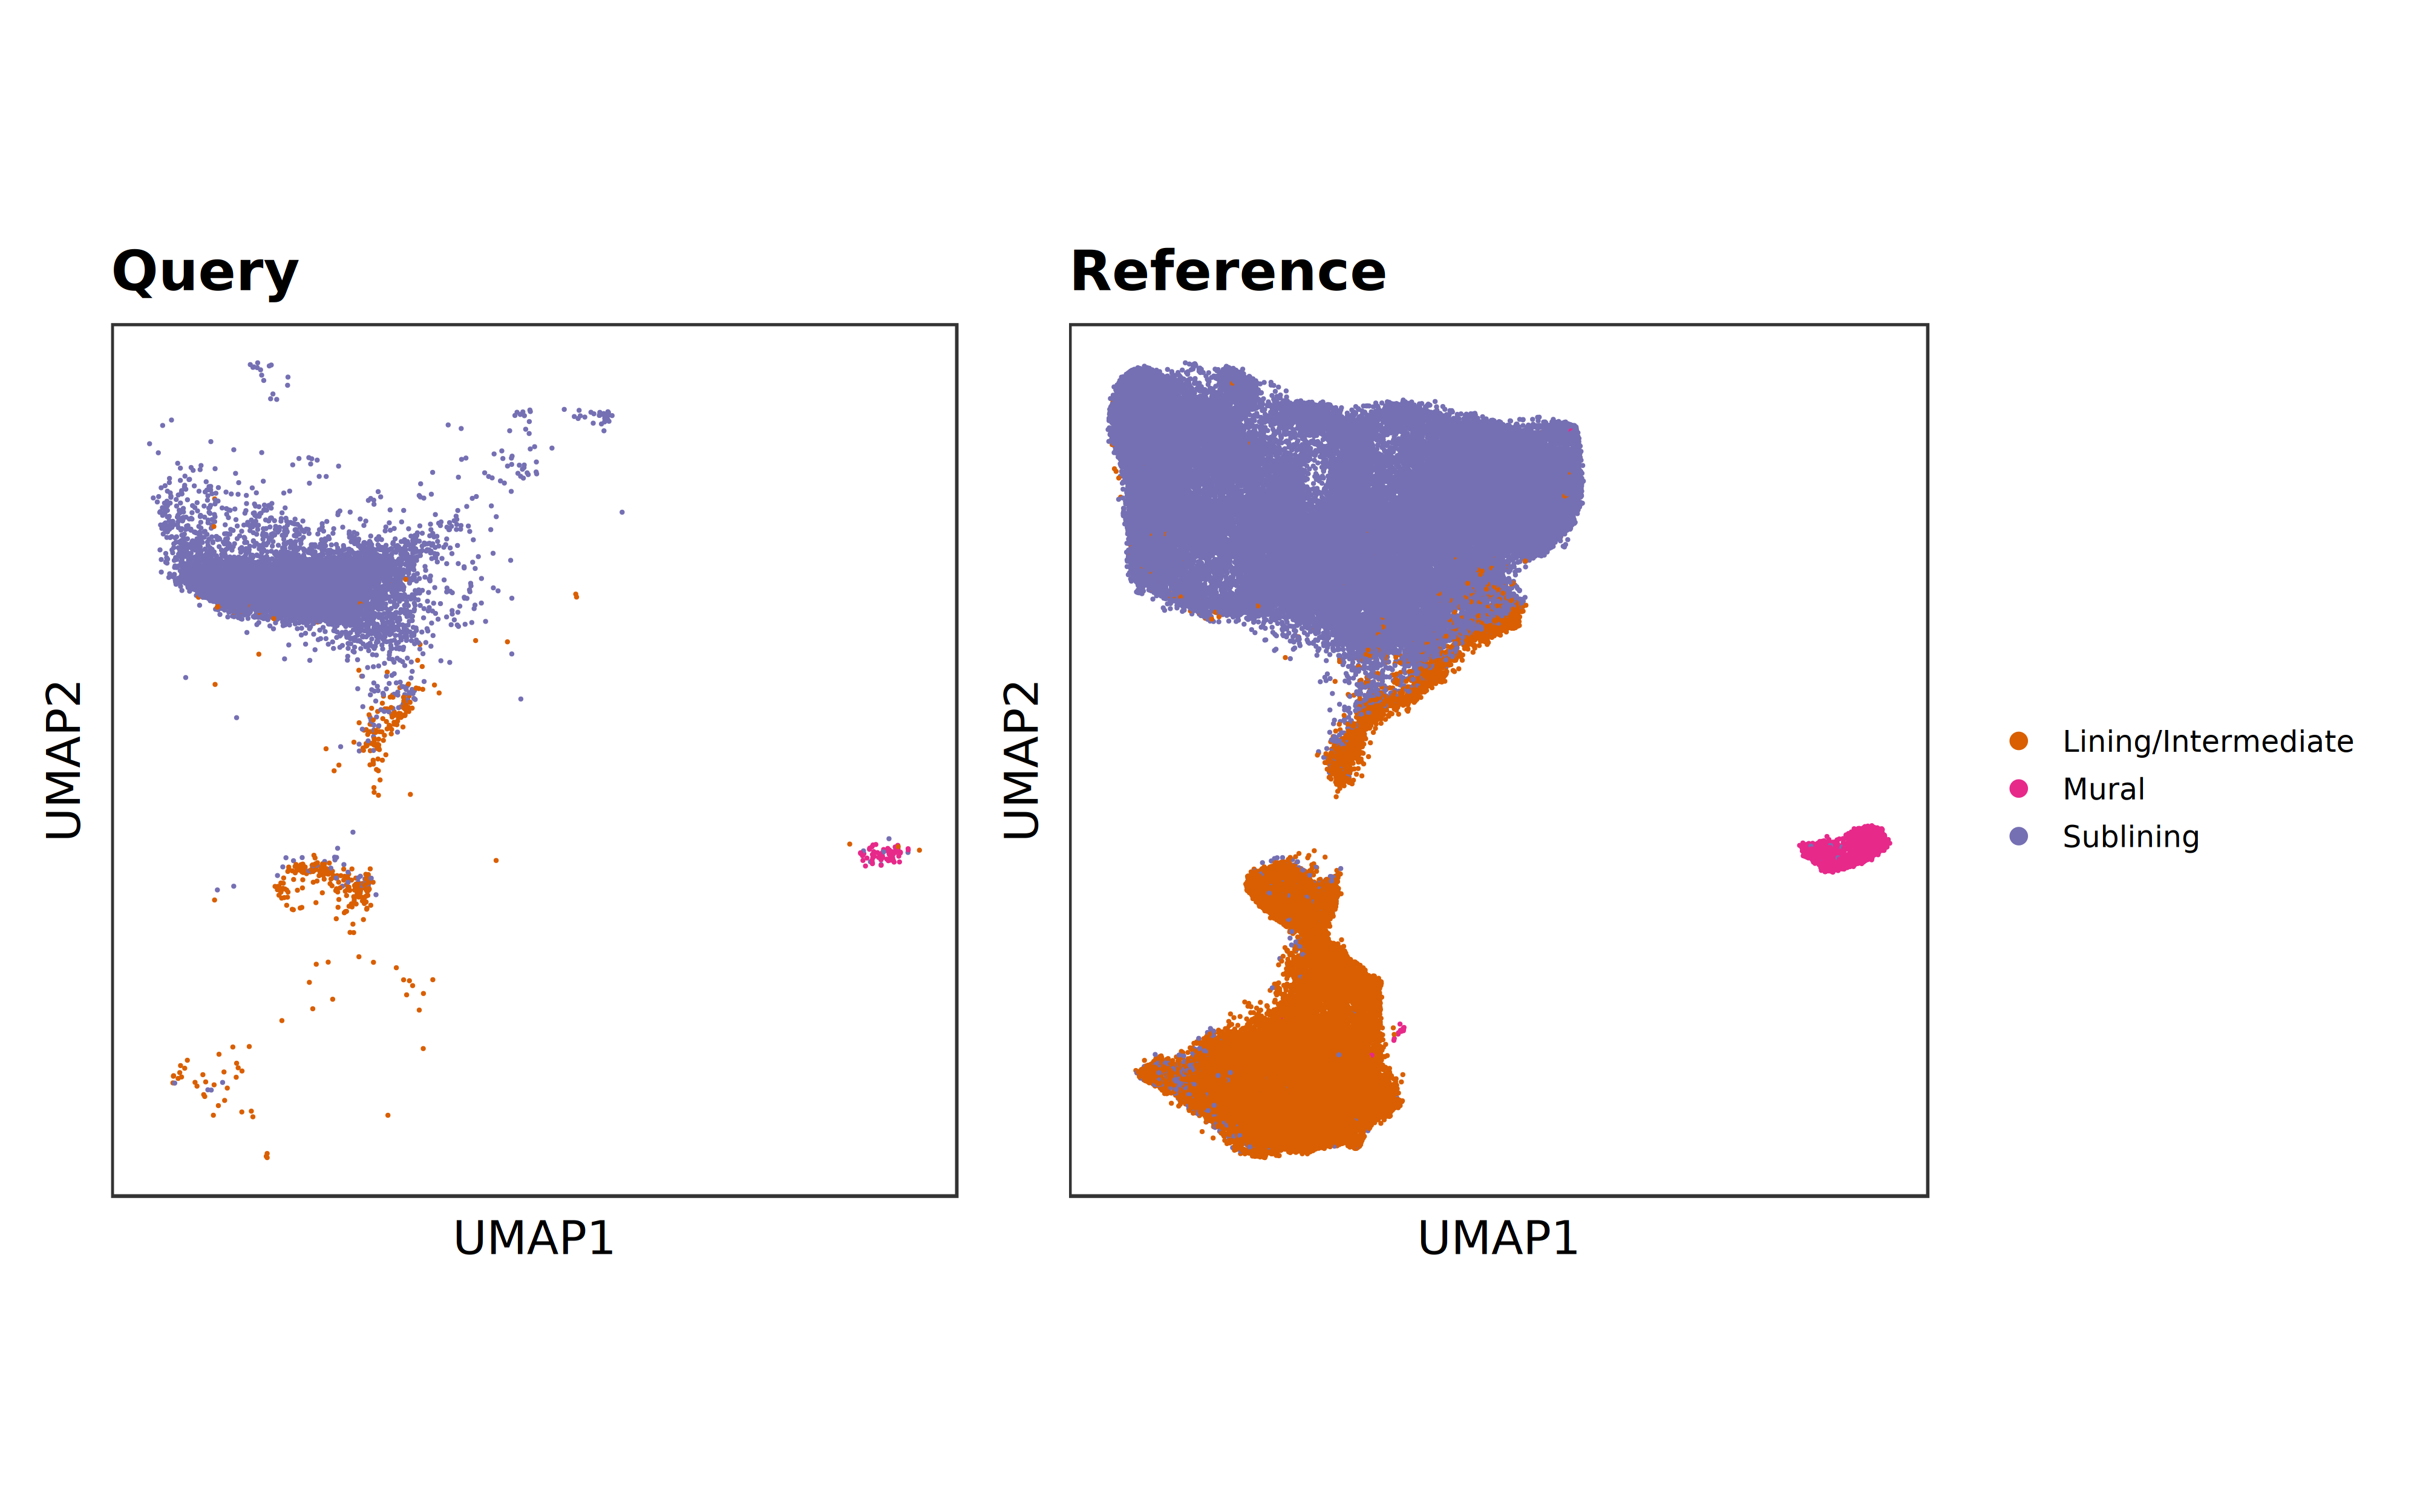

In [47]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 500)
query_umap_high_level + reference_umap_high_level
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/Ian_old_scrna_experiment/reference_mapping_umap_high_level_ct_FB.png",
       height=5,
       width=8,
       dpi=500)

# Plot cell type proportion per experiment design

In [52]:
experiment_design_info <- read_xlsx("/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/IM032 pooling information.xlsx", skip=1)[, c(1, 6:9)]
colnames(experiment_design_info) <- c("experiment_name", "celltype", "donorID", "soluble_factors", "wMac")

New names:
• `Cell type` -> `Cell type...2`
• `Donor/Patient ID` -> `Donor/Patient ID...3`
• `Soluble factors` -> `Soluble factors...4`
• `Co-cultured?` -> `Co-cultured?...5`
• `Cell type` -> `Cell type...6`
• `Donor/Patient ID` -> `Donor/Patient ID...7`
• `Soluble factors` -> `Soluble factors...8`
• `Co-cultured?` -> `Co-cultured?...9`


In [53]:
experiment_design_info %>%
    mutate(wMac=ifelse(wMac=="w/ mac", "+Mac", "-Mac"),
           design=paste(soluble_factors, wMac, sep="")) -> experiment_design_info
experiment_design_info %>%
    mutate(experiment_name=paste(experiment_name, "_5prime_gex", sep="")) -> experiment_design_info

In [57]:
plot_data %>%
    select(orig.ident, projected_cell_label, high_level_ct) %>%
    left_join(experiment_design_info %>% select(experiment_name, design), by=c("orig.ident"="experiment_name")) -> plot_data_exp_design

In [59]:
plot_data_exp_design %>%
    count(design, high_level_ct) %>%
    group_by(design) %>%
    mutate(prop = n / sum(n)) -> plot_data_exp_design_proportion
reference_plot_data %>%
    count(high_level_ct) %>%
    mutate(prop=n/sum(n)) -> reference_prop
reference_prop$design <- "Reference"
reference_prop <- reference_prop[, colnames(plot_data_exp_design_proportion)]
plot_data_exp_design_proportion <- rbind(reference_prop, plot_data_exp_design_proportion)
plot_data_exp_design_proportion$high_level_ct <- factor(plot_data_exp_design_proportion$high_level_ct, levels=c("Lining/Intermediate", "Sublining", "Mural"))
plot_data_exp_design_proportion$design <- factor(plot_data_exp_design_proportion$design, levels=c("Reference", "MCSF-Mac", "MCSF+Mac", "MCSF+TGFB-Mac", "MCSF+TGFB+Mac"))

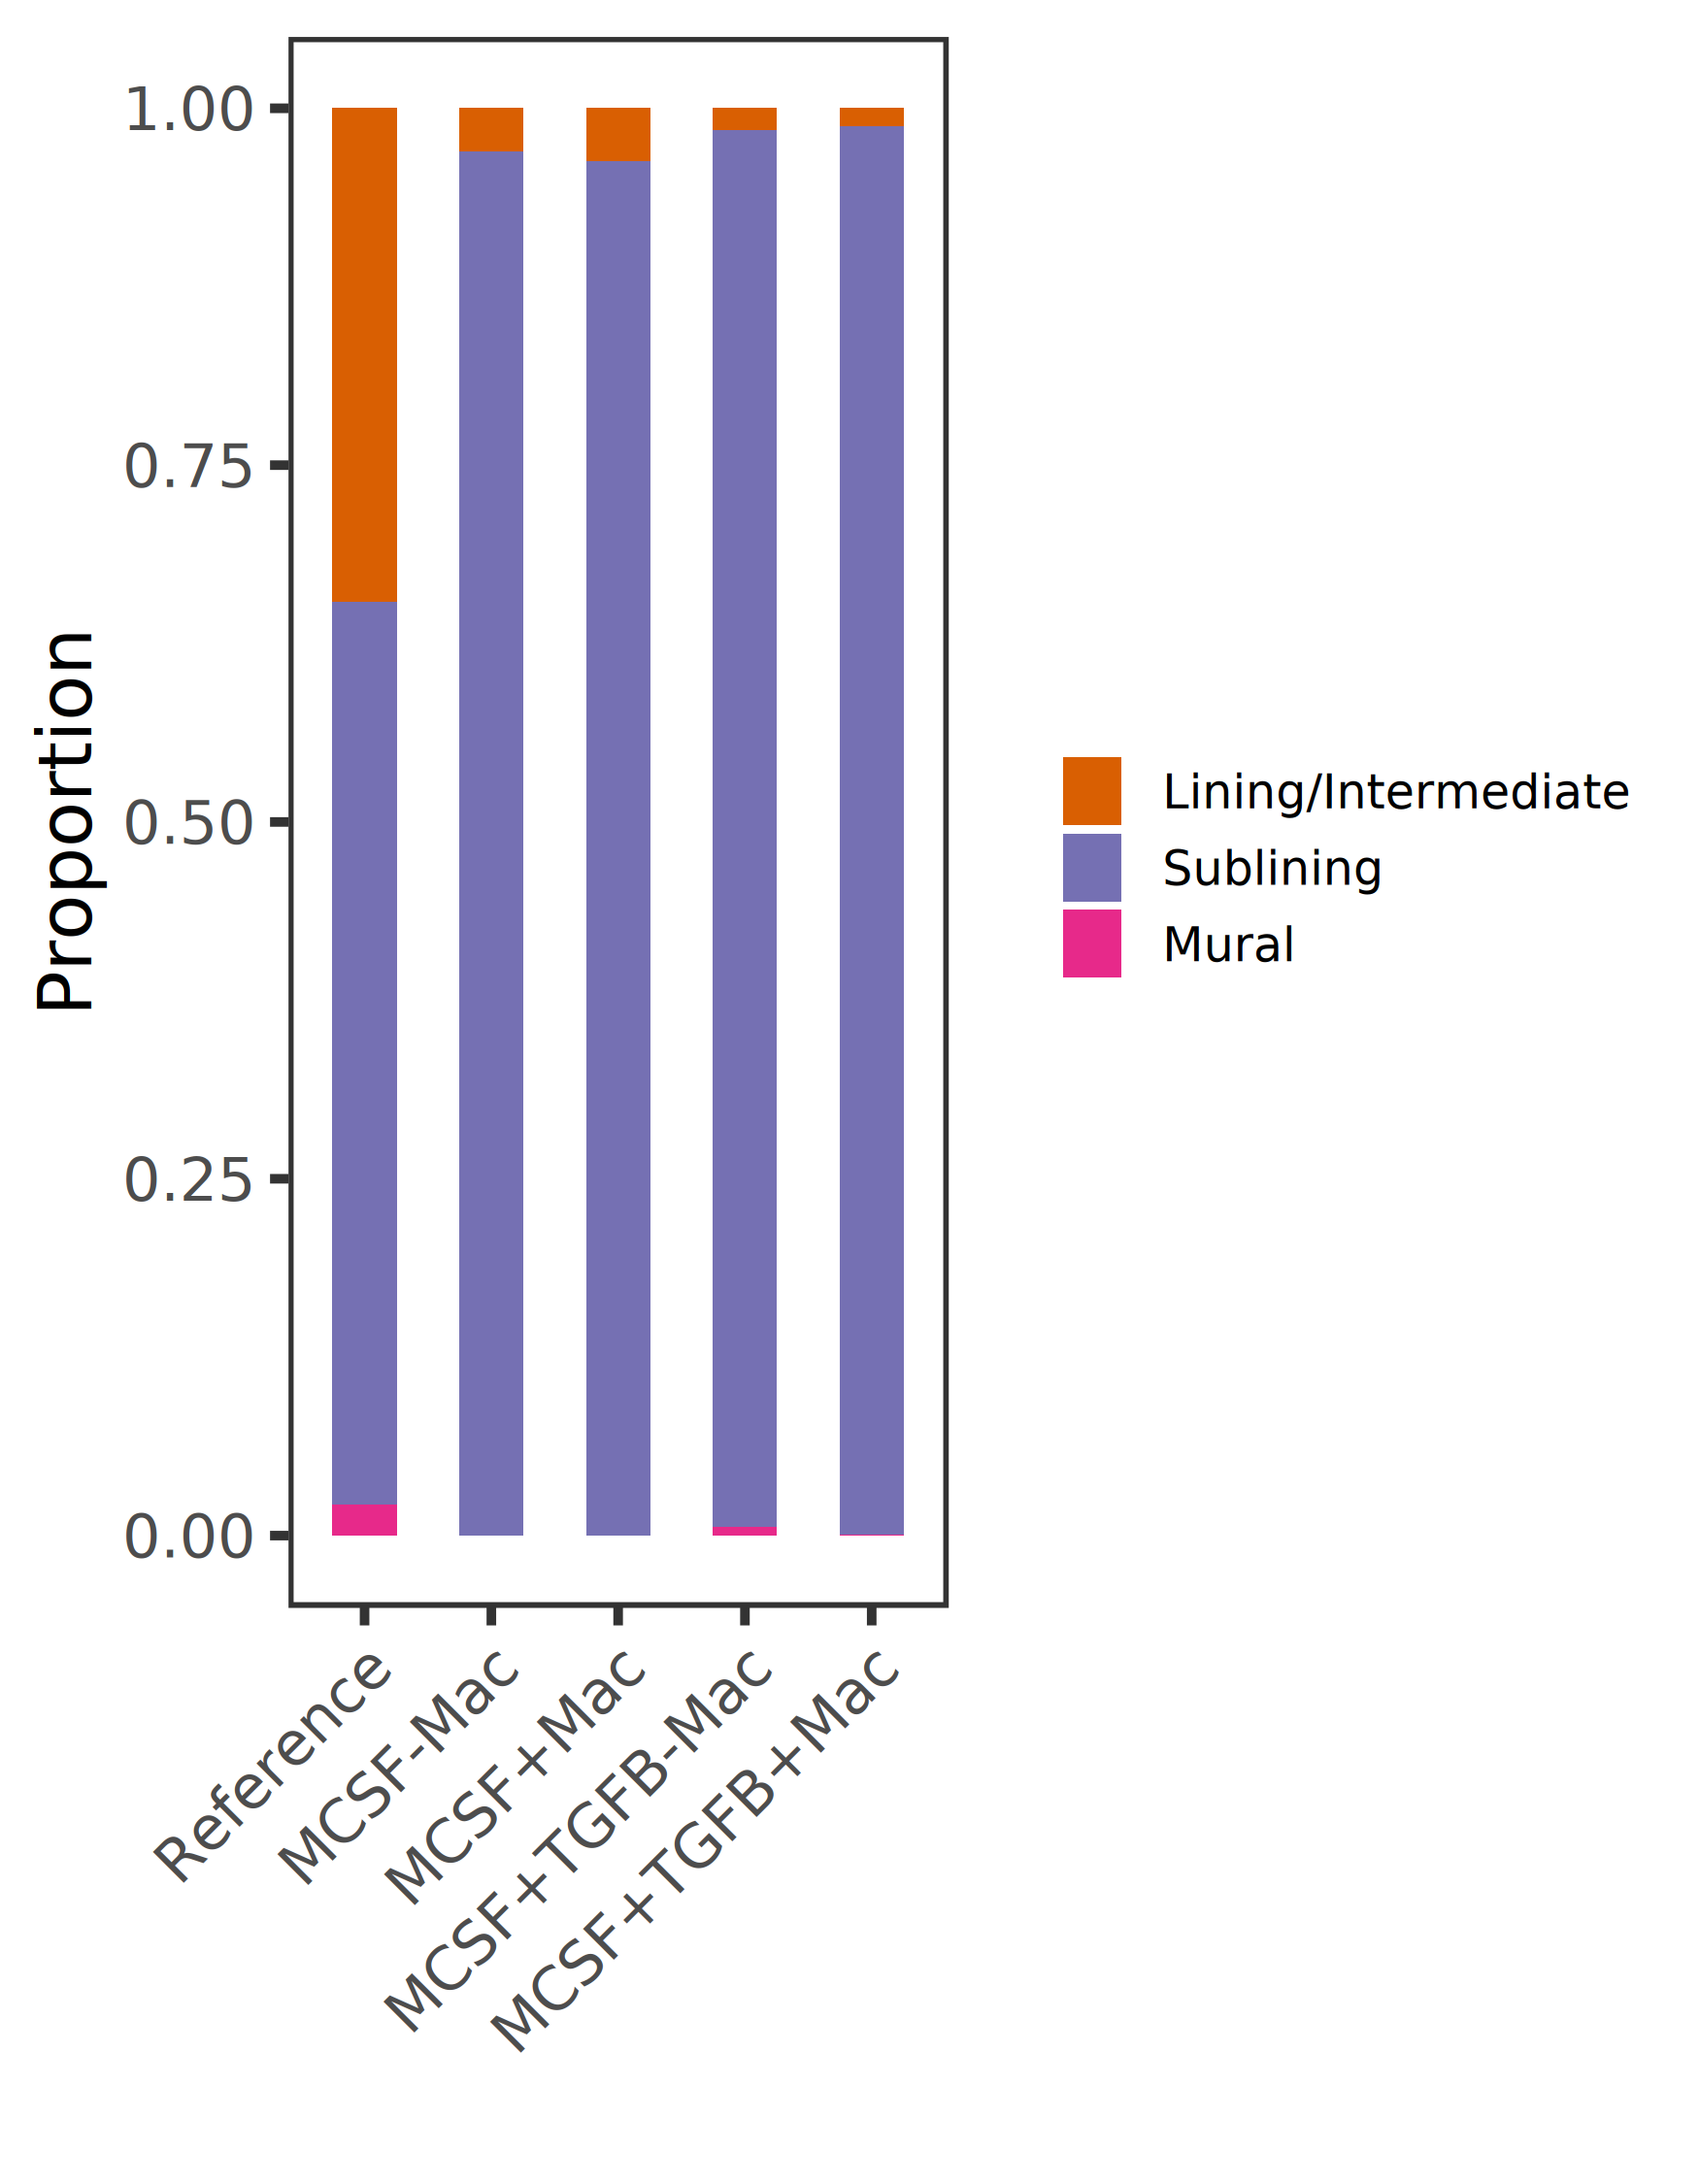

In [61]:
options(repr.plot.width = 3.5, repr.plot.height = 4.5, repr.plot.res = 500)
ggplot(plot_data_exp_design_proportion, aes(design, prop, fill=high_level_ct)) +
    geom_bar(stat="identity", position=position_stack(), width=0.5) +
    scale_fill_manual(values=high_level_ct_pal) +
    theme_bw() +
    theme(legend.key.height=unit(0.4, 'cm'),
          plot.title=element_text(face="bold"),
          legend.key.width=unit(0.35, 'cm'),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7),
          panel.grid = element_blank(),
          axis.text.x=element_text(angle=45, hjust=1)) +
    labs(fill="", x="", y="Proportion")
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/Ian_old_scrna_experiment/reference_mapping_proportion_high_level_ct_FB.png",
       height=4.5,
       width=3.5,
       dpi=500)

In [93]:
plot_data_exp_design %>%
    count(design, projected_cell_label) %>%
    group_by(design) %>%
    mutate(prop = n / sum(n), 
           ct = projected_cell_label) %>%
    select(-projected_cell_label)-> plot_data_exp_design_proportion_finegrained

In [94]:
reference_plot_data %>%
    count(cluster_name) %>%
    mutate(prop=n/sum(n), 
           ct = cluster_name) %>%
    select(-cluster_name) -> reference_prop_finegrained
reference_prop_finegrained$design <- "Reference"
reference_prop_finegrained <- reference_prop_finegrained[, colnames(plot_data_exp_design_proportion_finegrained)]
plot_data_exp_design_proportion_finegrained <- rbind(reference_prop_finegrained, plot_data_exp_design_proportion_finegrained)
plot_data_exp_design_proportion_finegrained$design <- factor(plot_data_exp_design_proportion_finegrained$design, levels=c("Reference", "MCSF-Mac", "MCSF+Mac", "MCSF+TGFB-Mac", "MCSF+TGFB+Mac"))

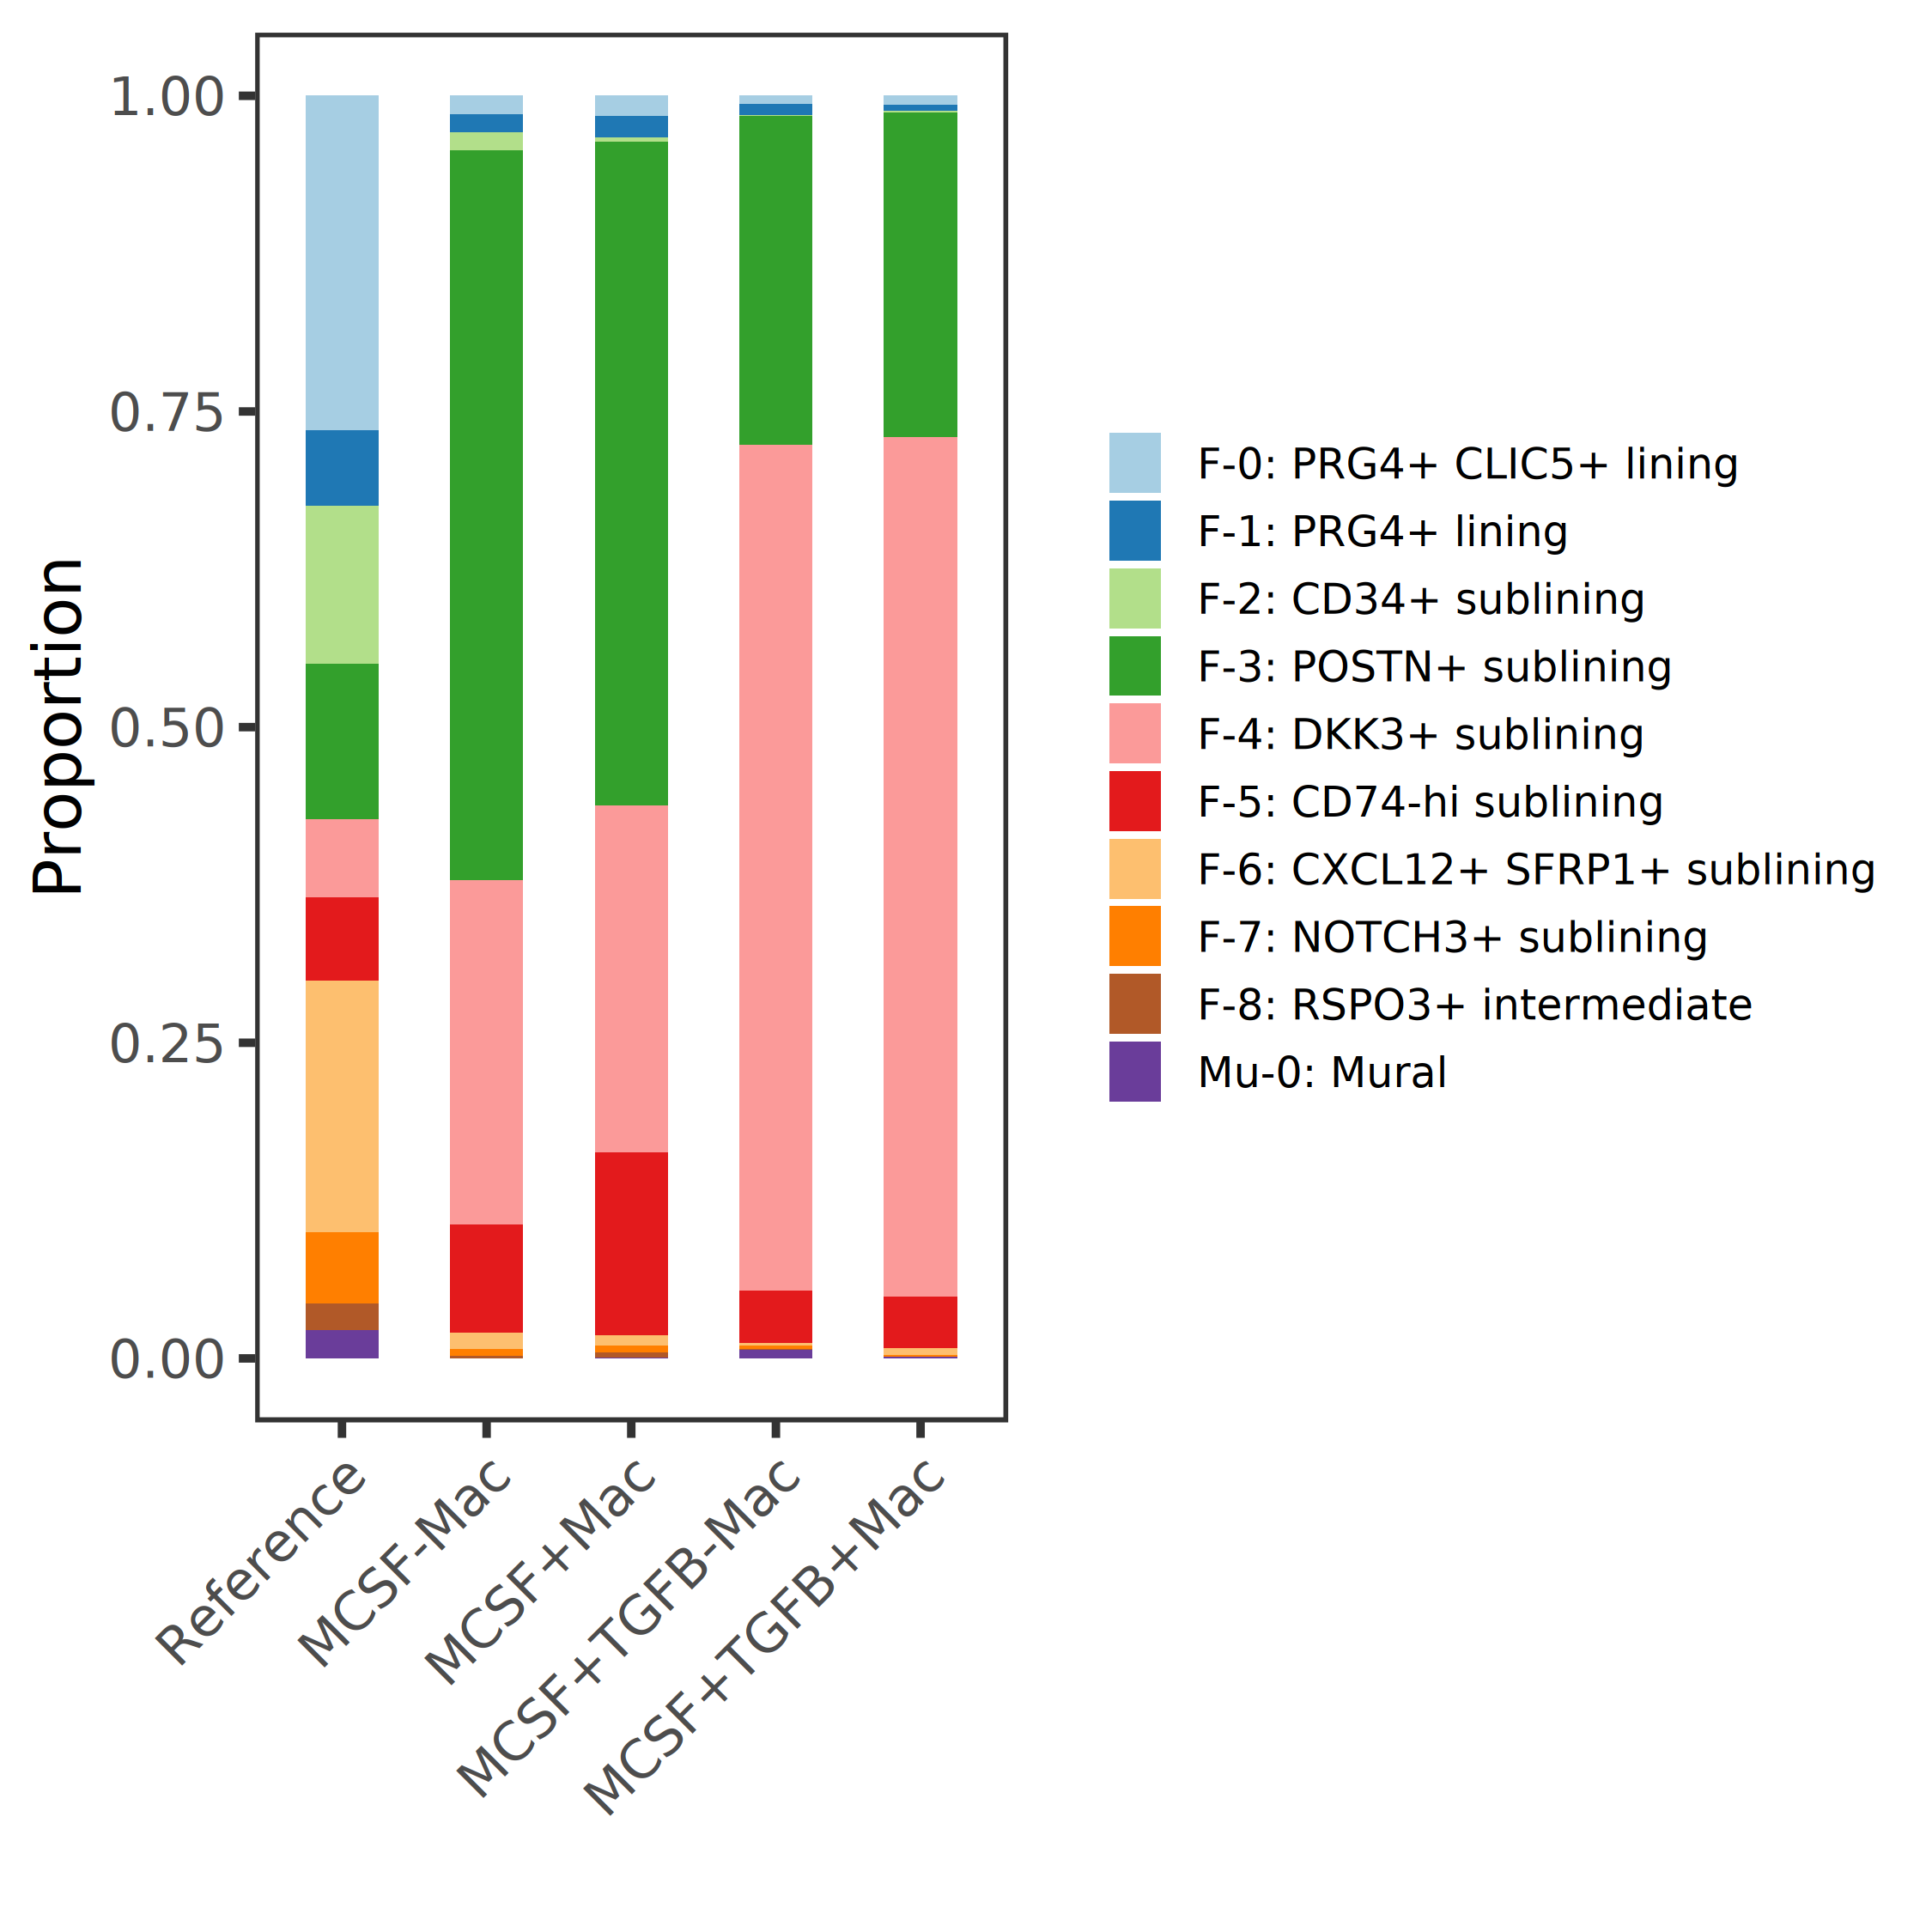

In [95]:
options(repr.plot.width = 4.5, repr.plot.height = 4.5, repr.plot.res = 500)
ggplot(plot_data_exp_design_proportion_finegrained, aes(design, prop, fill=ct)) +
    geom_bar(stat="identity", position=position_stack(), width=0.5) +
    scale_fill_manual(values=cluster_colors) +
    theme_bw() +
    theme(legend.key.height=unit(0.4, 'cm'),
          plot.title=element_text(face="bold"),
          legend.key.width=unit(0.35, 'cm'),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7),
          panel.grid = element_blank(),
          axis.text.x=element_text(angle=45, hjust=1)) +
    labs(fill="", x="", y="Proportion")
ggsave("/data1/deyk/harry/RA_Xenium/results/figures/Ian_old_scrna_experiment/reference_mapping_proportion_FB.png",
       height=4.5,
       width=4.5,
       dpi=500)

# Visualize some dotplots

In [65]:
merged_fibroblast_query@meta.data %>%
    select(orig.ident) %>%
    left_join(experiment_design_info %>% select(experiment_name, design), by=c("orig.ident"="experiment_name")) %>%
    select(-orig.ident) -> design_df_add
design_df_add <- data.frame(design_df_add)
rownames(design_df_add) <- colnames(merged_fibroblast_query)

In [102]:
merged_fibroblast_query <- ScaleData(merged_fibroblast_query)

Centering and scaling data matrix



In [66]:
merged_fibroblast_query <- AddMetaData(merged_fibroblast_query, design_df_add)
merged_fibroblast_query$design <- gsub("\\+", "plus", merged_fibroblast_query$design)
merged_fibroblast_query$design <- gsub("\\-", "minus", merged_fibroblast_query$design)

In [103]:
gene_lists <- data.frame(read_xlsx("/data1/deyk/harry/RA_Xenium/data/Ian_old_scRNA_07062025/gene_list_dotplot_07142025.xlsx"))

In [202]:
dot_plot_all <- lapply(seq_len(ncol(gene_lists)), function(idx){
    genes.tmp <- gene_lists[, idx]
    genes.tmp <- genes.tmp[!is.na(genes.tmp)]
    # Scale first then take average, this resolves problem with scaling the average expression when the number of groups is low
    avg_exp <- AverageExpression(object=merged_fibroblast_query, group.by="design", slot="scale.data", features=genes.tmp)
    percent_expressing <- Percent_Expressing(seurat_object=merged_fibroblast_query, features=genes.tmp, group_by="design")
    percent_expressing %>%
        mutate(gene=rownames(.)) %>%
        pivot_longer(!gene, names_to="design", values_to="pct_exp") -> percent_expressing
    percent_expressing$design <- gsub("plus", "+", percent_expressing$design)
    percent_expressing$design <- gsub("minus", "-", percent_expressing$design)
    scaled_avg_exp <- avg_exp$RNA
    # scaled_avg_exp <- t(scale(t(avg_exp$RNA)))
    # scaled_avg_exp <- MinMax(scaled_avg_exp, max=2.5, min=-2.5)
    data.frame(scaled_avg_exp) %>%
        mutate(gene=rownames(.)) %>%
        pivot_longer(!gene, names_to="design", values_to="z_avg_exp") -> scaled_avg_exp
    scaled_avg_exp$design <- gsub("plus", "+", scaled_avg_exp$design)
    scaled_avg_exp$design <- gsub("minus", "-", scaled_avg_exp$design)
    percent_expressing %>%
        left_join(scaled_avg_exp, by=c("gene", "design")) -> design_dot_plot
    design_dot_plot$design <- gsub("plus", "+", design_dot_plot$design)
    design_dot_plot$design <- gsub("minus", "-", design_dot_plot$design)
    # color_scale_breaks <- round(unname(c(quantile(design_dot_plot$z_avg_exp, 0.1), 0, quantile(design_dot_plot$z_avg_exp, 0.9))), 2)
    color_scale_breaks <- c(quantile(design_dot_plot$z_avg_exp, 0.02), quantile(design_dot_plot$z_avg_exp, 0.98))
    ggplot(design_dot_plot, aes(gene,
                              design,
                              color=z_avg_exp,
                              size=pct_exp)) +
    scale_size_continuous(range=c(0, 4), breaks=seq(25, 75, 25)) +
    scale_color_scico(palette="vik", midpoint=0, breaks=color_scale_breaks, labels=c("Low", "High")) +
    geom_point() +
    theme_bw() +
    theme(axis.text.x=element_text(colour="black", angle=45, hjust=1, size=8),
          axis.text.y=element_text(colour="black", size=8),
          legend.key.height=unit(0.4, 'cm'),
          legend.key.width=unit(0.35, 'cm'),
          panel.grid.major=element_blank(),
          panel.grid.minor=element_blank(),
          legend.title=element_text(size=8),
          legend.text=element_text(size=7)) +
    ylab("") +
    xlab("") +
    labs(color="Scaled\nExpression",
         size="% Expressed") -> design_dot_plot_image
    design_dot_plot %>%
    select(-pct_exp) %>%
    pivot_wider(names_from=design, values_from=z_avg_exp) %>%
    tibble::column_to_rownames("gene") %>%
    as.matrix(.) -> dend_data
    dend_data  %>%
        dist() %>%
        hclust() %>%
        ggtree(branch.length="none") +
        layout_dendrogram() -> gene_dendro
    design_dot_plot_image %>%
    aplot::insert_top(gene_dendro, height=0.1)
})

In [211]:
sapply(gene_lists, function(col){
    sum(!is.na(col))
}) -> n_genes
n_genes/n_genes[1] -> width_ratio

In [ ]:
max()

In [217]:
save_dotplots <- lapply(seq_along(width_ratio), function(idx){
    name.tmp <- colnames(gene_lists)[idx]
    ggsave(plot=dot_plot_all[[idx]],
           filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/Ian_old_scrna_experiment/{name.tmp}_dotplot_experiment.png"),
           width=max(c(3, width_ratio[idx]*7+0.5)),
           height=2.8,
           dpi=500,
           limitsize=FALSE)
})